# Evaluation

This notebook contains all evaluation tables and plots. It start with the tables and then moves onto the plots. This includes several statistical computations, based on aggregated model results (included in `results.json`) as well as the actual predictions which have been saved to disk (but are not included in the repository). We also include some examples of recommendations, i.e. ranked lists of news titles.

In [2]:
from recs import *
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, roc_auc_score
from tqdm.notebook import trange, tqdm
from scipy.stats import linregress, ttest_rel
import matplotlib as mpl
import colorcet as cc
from recs.metrics import surprisal

GPU not detected.


In [23]:
# Get the results
df = pd.read_json('results.json').set_index('modelname')
df.rename(
    columns={
    'mean_mrr': 'MRR', 
    'auc': 'AUC', 'mean_epc':'EPC', 
    'mean_intra_list_diversity':'ILD', 
    'mean_surprisal': 'Surprisal', 
    'prediction_coverage':'Coverage', 
    'ndcg@5': 'nDCG@5', 'ndcg@10': 'nDCG@10'
    }, 
    index={
    'unbert_bert_large': 'Cross-encoder w/ BERT', 
    'unbert_glove_large': 'Cross-encoder w/ GloVe', 
    'BERT_large':'Bi-encoder w/ BERT',
    'bi_glove_large':'Bi-encoder w/ GloVe'},
    inplace=True)
df.index.name = None

## Table comparisons

In [3]:
#| label: tbl-baseline-comparison
#| tbl-cap: "A comparison of the baselines on the accuracy-based metrics"
def bold(s):
    is_max = s == s.max()
    return ['font-weight: bold; text-decoration: underline' if v else '' for v in is_max]

df[['AUC', 'MRR', 'nDCG@5', 'nDCG@10']].head(4) #.style.format(precision=4).apply(bold, axis=0)

,AUC,MRR,nDCG@5,nDCG@10
Random Recommender,0.4988,0.2210,0.2272,0.2940
MSN Recommender,0.5949,0.2215,0.2278,0.2948
Popularity Recommender,0.5355,0.2443,0.2585,0.3177
CB-Filtering,0.5751,0.2273,0.2318,0.2979


In [4]:
#| label: tbl-baseline-norm-comparison
#| tbl-cap: "A comparison of the baselines on the normative metrics"

df[['EPC', 'ILD', 'Surprisal', 'Coverage']].head(4) #.style.format(precision=4).apply(bold, axis=0).text_gradient(cmap='Blues_r', subset='ILD', vmin=0.15, vmax=0.25)

,EPC,ILD,Surprisal,Coverage
Random Recommender,1.8579,0.2517,11.3558,0.4892
MSN Recommender,1.3797,0.2460,8.5640,0.4992
Popularity Recommender,1.3340,0.1552,8.2623,0.1382
CB-Filtering,1.5386,0.2462,9.5014,0.4875


In [191]:
#| label: tbl-hard-comparison
#| tbl-cap: "A comparison on accuracy-based metrics"
cols = ['AUC', 'MRR', 'nDCG@5', 'nDCG@10']
df[cols].head(6) #.style.format(precision=4).apply(bold, axis=0

,AUC,MRR,nDCG@5,nDCG@10
Random Recommender,0.4988,0.2210,0.2272,0.2940
MSN Recommender,0.5949,0.2215,0.2278,0.2948
Popularity Recommender,0.5355,0.2443,0.2585,0.3177
CB-Filtering,0.5751,0.2273,0.2318,0.2979
Bi-encoder w/ BERT,0.7278,0.3011,0.3305,0.3949
Bi-encoder w/ GloVe,0.7395,0.3189,0.3511,0.4116


In [192]:
#| label: tbl-soft-comparison
#| tbl-cap: "A comparison on beyond-accuracy metrics"
cols = ['EPC', 'ILD', 'Surprisal', 'Coverage']
df[cols].head(6) #.style.format(precision=4).apply(bold, axis=0)

,EPC,ILD,Surprisal,Coverage
Random Recommender,1.8579,0.2517,11.3558,0.4892
MSN Recommender,1.3797,0.2460,8.5640,0.4992
Popularity Recommender,1.3340,0.1552,8.2623,0.1382
CB-Filtering,1.5386,0.2462,9.5014,0.4875
Bi-encoder w/ BERT,1.2587,0.2400,7.9081,0.2952
Bi-encoder w/ GloVe,1.2806,0.2434,8.0267,0.3246


In [193]:
#| label: tbl-accuracy-results
#| tbl-cap: "Main accuracy-based results"

cols = ['AUC', 'MRR', 'nDCG@5', 'nDCG@10']
df[cols][df.index.str.contains('Bi-encoder')].head(2) #.style.format(precision=4).apply(bold, axis=0)

,AUC,MRR,nDCG@5,nDCG@10
Bi-encoder w/ BERT,0.7278,0.3011,0.3305,0.3949
Bi-encoder w/ GloVe,0.7395,0.3189,0.3511,0.4116


In [24]:
# Top AUC of all small models
cols = ['AUC', 'MRR', 'nDCG@5', 'nDCG@10', 'EPC', 'ILD', 'Surprisal', 'Coverage']
df.query('dataset_size == "small"')[cols].sort_values('AUC', ascending=False).iloc[:10]

,AUC,MRR,nDCG@5,nDCG@10,EPC,ILD,Surprisal,Coverage
BERT_sm_div100_v2,0.7272,0.2887,0.3207,0.3825,1.3828,0.2527,7.8339,0.2180
BERT_sm_div100_v3,0.7272,0.2887,0.3207,0.3825,1.3828,0.2527,7.8339,0.2180
BERT_sm_div0_v3,0.7257,0.3018,0.3298,0.3923,1.3886,0.2511,7.8407,0.2283
BERT_sm_div50_v3,0.7246,0.3032,0.3338,0.3944,1.3861,0.2486,7.8624,0.2337
tradeoff_bert_v1.1.1,0.7229,0.2817,0.3090,0.3739,1.3819,0.2549,7.7181,0.2136
tradeoff_glove_1,0.7227,0.2957,0.3223,0.3844,1.4641,0.2421,8.2138,0.2733
tradeoff_glove_3,0.7219,0.2956,0.3262,0.3849,1.4450,0.2541,8.1187,0.2726
BERT_sm_div250_v3,0.7209,0.2824,0.3119,0.3735,1.3477,0.2609,7.6427,0.1704
BERT_sm_0,0.7206,0.2971,0.3278,0.3859,1.4227,0.2433,8.0133,0.2715
tradeoff_glove_1,0.7206,0.2966,0.3241,0.3847,1.4872,0.2414,8.3335,0.2740


> note how small Bert models have higher ILD, but lower Surprisal and coverage. 

## Side-by-side plots

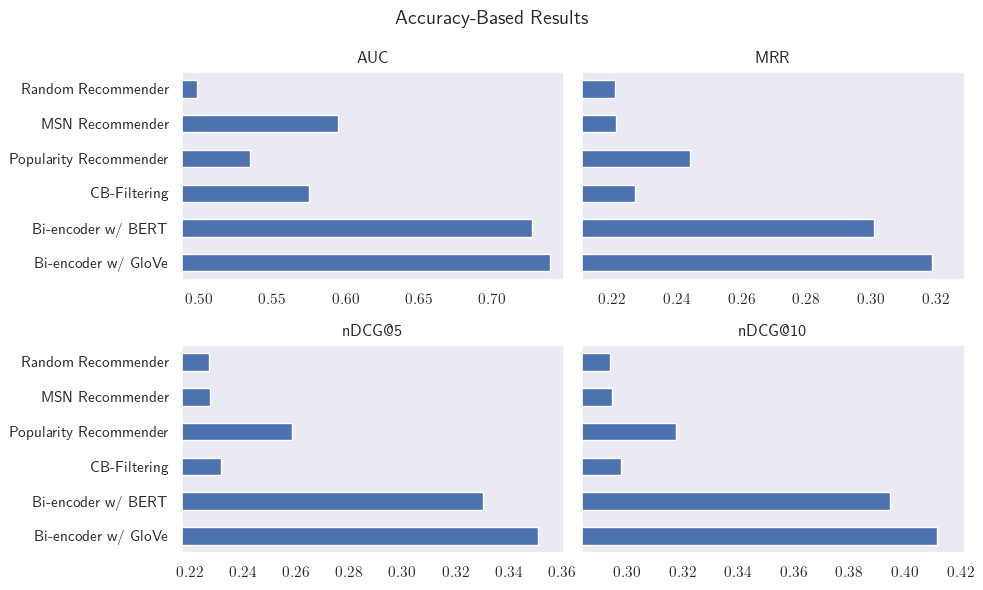

In [8]:
#| label: fig-all-comparison-hard
#| fig-cap: "Detailed comparison of all models on the hard metrics"

def top_hard(top, df):
    df = df.iloc[:top].iloc[::-1]
    cols = ['AUC', 'MRR', 'nDCG@5', 'nDCG@10']
    _, axs = plt.subplots(2, 2, sharey=True, figsize=(10,6))
    axs = axs.flatten()

    for i, col in enumerate(cols):
        df[col].plot.barh(ax=axs[i], title=col, ylabel='')
        axs[i].set_xlim((df[col].min() - 0.01,df[col].max()+  0.01))

    plt.suptitle('Accuracy-Based Results')
    plt.tight_layout()
    plt.show()

top_hard(6, df)

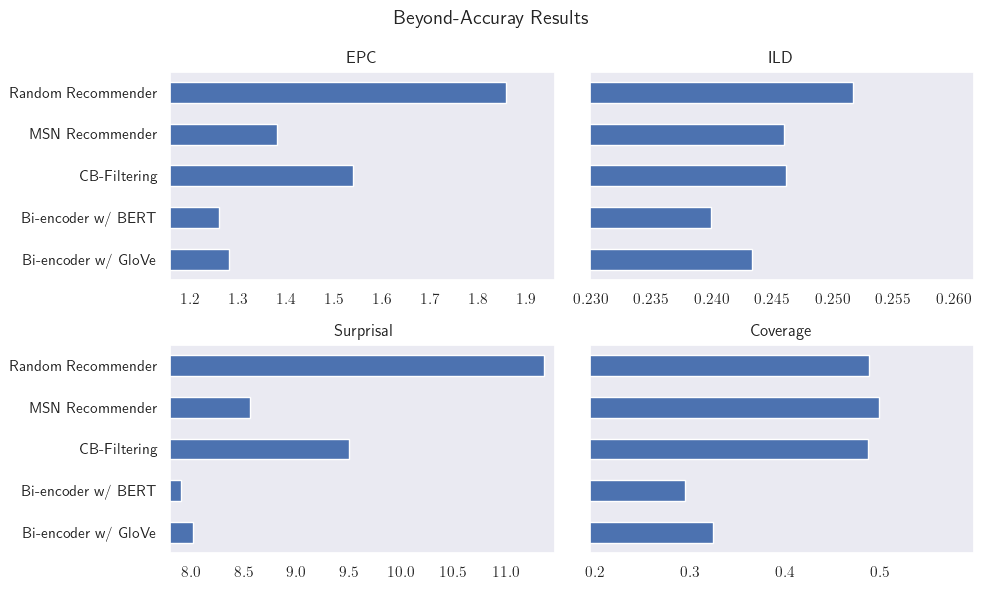

In [9]:
#| label: fig-all-comparison-soft
#| fig-cap: "Detailed comparison of all models on the normative metrics"

def top_soft(top, df):
    df = df.drop('Popularity Recommender').iloc[:top].iloc[::-1]
    cols = ['EPC', 'ILD', 'Surprisal', 'Coverage']
    _, axs = plt.subplots(2, 2, sharey=True, figsize=(10,6))
    axs = axs.flatten()

    for i, col in enumerate(cols):
        df[col].plot.barh(ax=axs[i], title=col, ylabel='')
        axs[i].set_xlim((df[col].min() - 0.1,df[col].max() +  0.1))
        if i == 1:
            axs[1].set_xlim((df[col].min() - 0.01,df[col].max() +  0.01))

    plt.suptitle('Beyond-Accuray Results')
    plt.tight_layout()
    plt.show()

top_soft(5, df)

In [ ]:
# Load data
data = DataLoader(data_size='large')
histories, data.test_imprs, labels = data.init_padded_behaviors(data.test)
ds = data.get_dataset(data.test) # gets data.test_labels
del ds

# Load preds
bi_glove = np.load(data_folder/'glove_300_large.npy')
cross_glove = np.load(data_folder/'unbert_glove_large.npy')
CB_rec = np.load(data_folder/'CB-Filtering.npy')
pop_rec = np.load(data_folder/'Popularity_Recommender.npy')
MSN_rec = np.load(data_folder/'MSN_Recommender.npy')

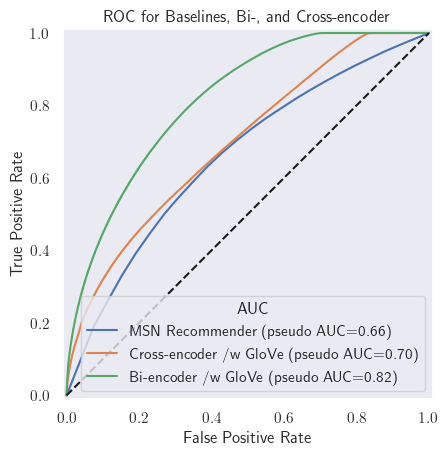

In [13]:
#| label: fig-roc-plot 
#| fig-cap: "Pseudo ROC: treating the padding as 0."

model_dict = {
    'MSN Recommender': MSN_rec,
    'Cross-encoder /w GloVe': cross_glove,
    'Bi-encoder /w GloVe': bi_glove,
    }

y_true = data.test_labels
y_true = np.where(y_true == -1, 0, y_true)

fig, ax = plt.subplots()
for i, (modelname, preds) in enumerate(model_dict.items()):    
    seq_len = preds.shape[1]
    y_true_ = y_true[:,:seq_len]

    flat_labels = y_true_.flatten()
    flat_preds = preds.flatten()
    
    roc_auc = roc_auc_score(flat_labels, flat_preds)
    
    RocCurveDisplay.from_predictions(y_true=flat_labels, y_pred=flat_preds, ax=ax, label=f"{modelname} (pseudo AUC={roc_auc:.2f})") 
    
ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('ROC for Baselines, Bi-, and Cross-encoder')
ax.set_ylabel('True Positive Rate')
ax.set_xlabel('False Positive Rate')
plt.legend(title='AUC')
plt.show()


---

## Bar charts

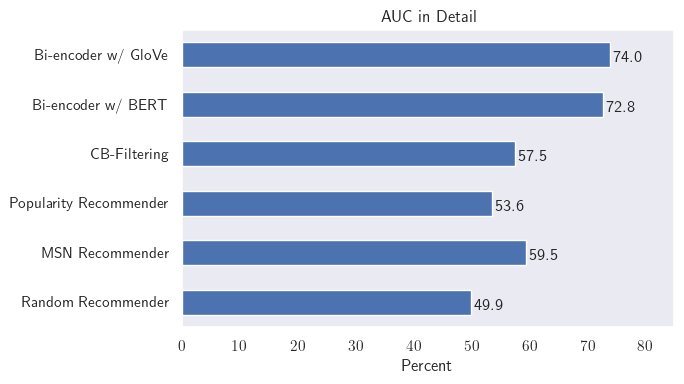

In [10]:
#| fig-cap: "AUC for selected the models."
#| label: fig-auc-with-numbers

plot_df = df['AUC'].iloc[:6].round(4) * 100

ax = plot_df.plot.barh(title='AUC in Detail',
                   xlabel='Percent', ylabel='', figsize=(7,4))

for x, y in zip(plot_df.values, ax.get_yticks()):
    ax.text(x+.5 , y-0.15, round(x, 1))

plt.xlim(0, 85)
plt.tight_layout()
plt.show()

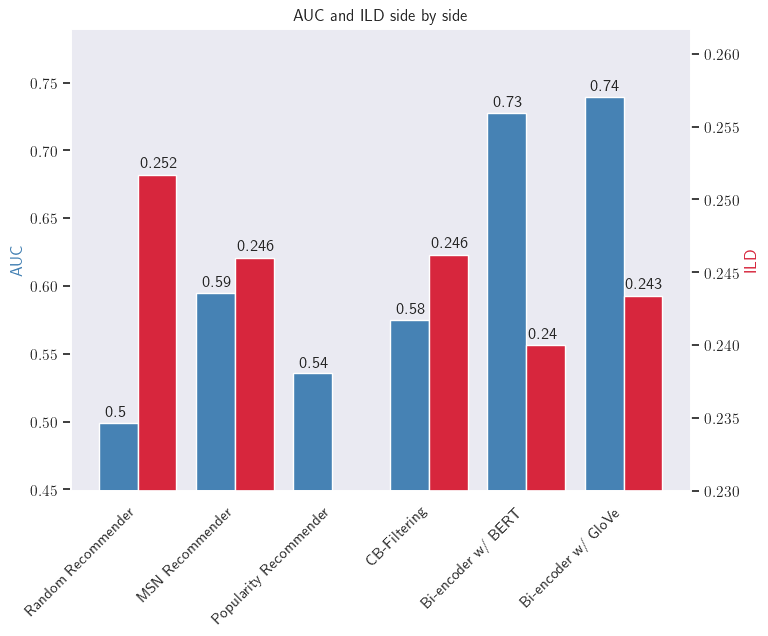

In [ ]:
#| fig-cap: "AUC and ILD side by side"
#| label: fig-auc-and-ild
#| fig-size: 

df.drop('timestamp', axis=1, inplace=True, errors='ignore')
plot_df = df.iloc[:6].round(4)

fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()

bar_width = 0.4
bars = range(len(plot_df))

bars1 = ax1.bar(bars, plot_df['AUC'], width=bar_width, label='AUC', color='steelblue', align='center')
bars2 = ax2.bar([i + bar_width for i in bars], plot_df['ILD'], 
                width=bar_width, label='ILD', color='#D7263D', align='center')

for x, y in zip(ax1.get_xticks(), plot_df.AUC.values):
    ax1.text(x+0.86, y+0.005, round(y, 2))

for x, y in zip(ax2.get_xticks(), plot_df.ILD.values):
    if y > 0.16: 
        ax2.text(x+1.22, y+0.0005, round(y, 3))

ax1.set_xlabel('')
ax1.set_ylabel('AUC', color='steelblue')
ax2.set_ylabel('ILD', color='#D7263D')
ax1.set_title('AUC and ILD Side by Side')
ax1.set_ylim(plot_df['AUC'].min() - 0.05, plot_df['AUC'].max() + 0.05)
ax2.set_ylim(0.23, plot_df['ILD'].max() + 0.01)
ax1.set_xticks([i + bar_width / 2 for i in bars])
ax1.set_xticklabels(plot_df.index, rotation=45, ha='right')

plt.grid(visible=False)
plt.show()


---

## Trade-off - linreg plots for glove
 
Correlation between AUC and ranking metrics, MRR and nDCG@10.

In [3]:
tradeoff_df = df[df.index.str.contains('tradeoff')]
tradeoff_df = tradeoff_df.sort_values('lambda_diversity') #.iloc[:-1] 
# tradeoff_df[['AUC', 'ILD', 'lambda_diversity']]

In [ ]:
# FYI: many metrics correlate...
tradeoff_df[['AUC', 'MRR', 'nDCG@5', 'nDCG@10', 'EPC',
       'ILD', 'Surprisal', 'Coverage']].corr().iloc[:1,1:]

,MRR,nDCG@5,nDCG@10,EPC,ILD,Surprisal,Coverage
AUC,0.947517,0.960395,0.971172,0.331351,-0.609141,0.271952,0.891713


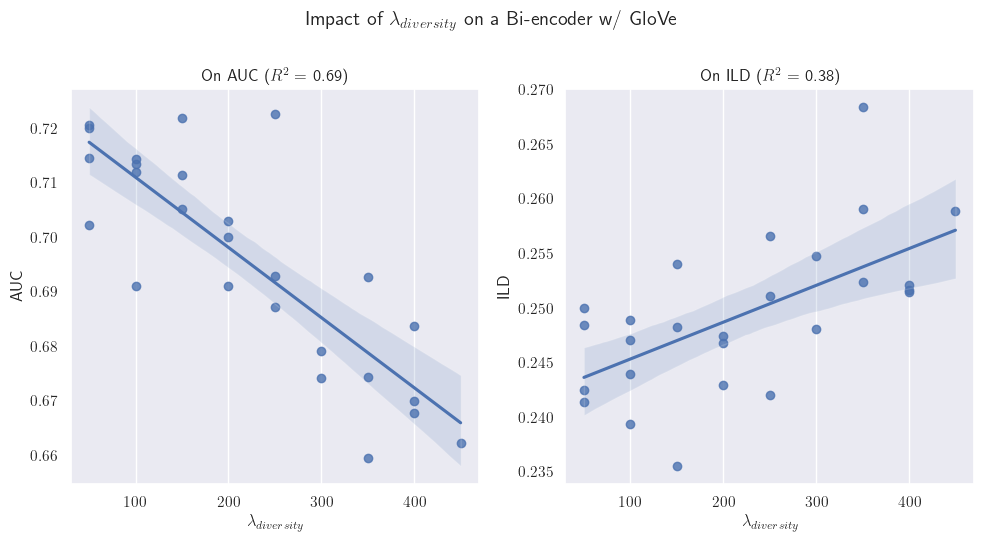

In [ ]:
#| fig-cap: "The impact of `lambda_diversity` on AUC and ILD"
#| label: fig-auc-vs-ild-glove

corr1 = tradeoff_df[['lambda_diversity', 'AUC']].corr().values[1,0]**2
corr2 = tradeoff_df[['ILD', 'lambda_diversity']].corr().values[1,0]**2

fig, axs = plt.subplots(1,2, figsize=(10,5))
sns.regplot(tradeoff_df, x='lambda_diversity', y='AUC', ax=axs[0])
sns.regplot(tradeoff_df, x='lambda_diversity', y='ILD', ax=axs[1])

axs[0].set_title("On AUC")
axs[1].set_title("On ILD ($R^2$ = " + f"{corr2:.2f})")
axs[0].set_xlabel("$\lambda_{diversity}$")
axs[1].set_xlabel("$\lambda_{diversity}$")

axs[0].grid(True, 'major', axis='x')
axs[1].grid(True, 'major', axis='x')

plt.tight_layout()
plt.suptitle('Impact of $\lambda_{diversity}$ on a Bi-encoder w/ GloVe', y=1.08)
plt.show()

In [ ]:
res = linregress(tradeoff_df.lambda_diversity, tradeoff_df.ILD)
res.slope, res.pvalue, res.rvalue**2

(3.3695445920303614e-05, 0.0008584518869316192, 0.3764223683748148)

### Key insights:

**Regression coefficient**: increasing λ_diversity by 100 increases ILD by 0.00345.

**The p-value for the slope coefficient** shows that the relationship is statistically significant — i.e. unlikely to be due to random chance. The association was statistically significant (p = 0.043), suggesting that changes in `lambda_diversity` are reliably associated with changes in ILD, though other factors likely contribute to the majority of the variance.

**R-squared (R²)** shows *how much of the variance* in the dependent variable is explained by the predictor. The model explained approximately 30% of the variance in ILD (R² = 0.298).

In [ ]:
# The tradeoff between ILD and AUC is nearly -0.70
tradeoff_df[['lambda_diversity', 'AUC', 'ILD',]].corr()

,lambda_diversity,AUC,ILD
lambda_diversity,1.000000,-0.818586,0.546167
AUC,-0.818586,1.000000,-0.687565
ILD,0.546167,-0.687565,1.000000


We obtained slightly better regularisation effect from BERT: approx. 0.05 more ILD.

In [19]:
df_divs = df[df.index.str.contains(r'BERT_|tradeoff')].copy()
df_divs['embedding'] = 'Glove'
df_divs.loc[df_divs.index.str.contains(r'BERT_'),'embedding'] = 'BERT'

In [ ]:
# the bert embeddings respond better to diversity regulation 
grouped = df_divs.groupby(['embedding', 'lambda_diversity'])[['AUC', 'ILD']].mean()

# This is most interesting here: BERT gets 0.006 more on ILD
grouped.loc['Glove'].ILD.mean() - grouped.loc['BERT'].loc[50:550].ILD.mean()

-0.005776710758377379

In [ ]:
# Moderately interesting: Bert also gets 0.005 more AUC after regularisation
grouped.loc['Glove'].AUC.mean() - grouped.loc['BERT'].AUC.mean()

-0.004486970899470921


---

## Trade-off plots for BERT


In [ ]:
tradeoff_df = df[
    df.index.str.contains(r'BERT|bert', regex=True) \
    & ~df.index.str.contains(r'Cross', regex=True)
    ]

tradeoff_df = tradeoff_df.sort_values('lambda_diversity')
tradeoff_df.fillna(0, inplace=True)
cols = ['AUC', 'Surprisal', 'EPC', 'lambda_novelty', 'lambda_diversity', 'ILD']
# tradeoff_df[cols]


### nov_tradeoff

In [83]:
nov_tradeoff = tradeoff_df.query("lambda_diversity == 0 and AUC > 0.68 and lambda_novelty < 17")
# nov_tradeoff[cols]

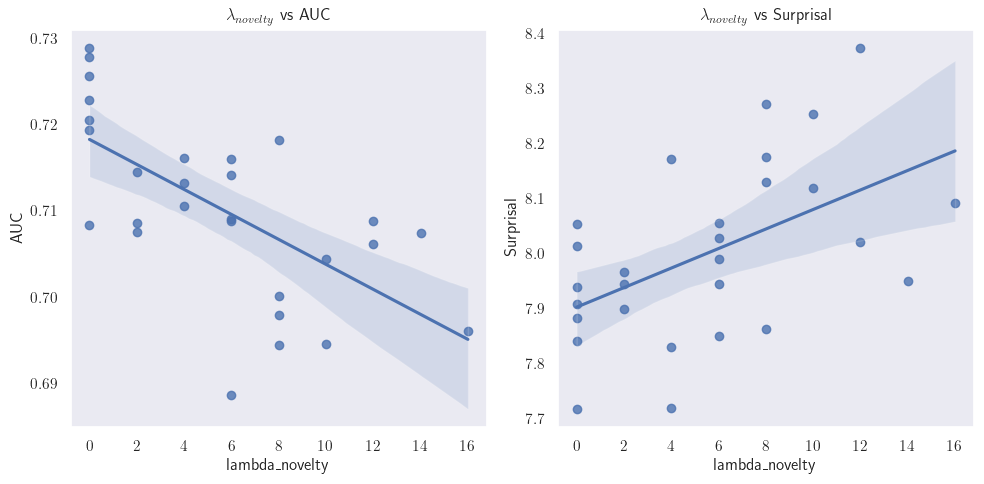

In [ ]:
#| fig-cap: "The impact of `lambda_novelty` on AUC and Surprisal w/ BERT"
#| label: fig-auc-vs-surprisal

fig, axs = plt.subplots(1,2, figsize=(10,5))
sns.regplot(nov_tradeoff, x='lambda_novelty', y='AUC', ax=axs[0])
# sns.regplot(nov_tradeoff.query('lambda_novelty < 14'), 
#             x='lambda_novelty', y='AUC', ax=axs[0], ci=False)
sns.regplot(nov_tradeoff, x='lambda_novelty', y='Surprisal',  ax=axs[1])
# sns.regplot(nov_tradeoff.query('lambda_novelty < 10'), 
#             x='lambda_novelty', y='Surprisal',  ax=axs[1], ci=False)

axs[0].set_title("$\lambda_{novelty}$ vs AUC")
axs[1].set_title("$\lambda_{novelty}$ vs Surprisal")
plt.tight_layout()
plt.show()

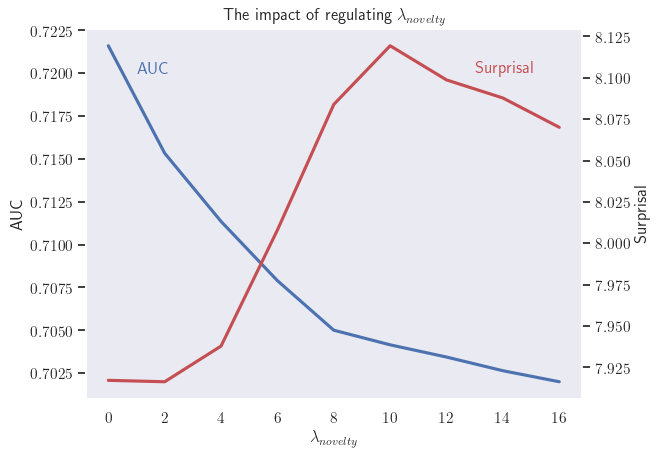

In [ ]:
#| fig-cap: "The impact of regularisation on AUC and Surprisal"
#| label: fig-impact-of-nov-reg

ax = sns.regplot(nov_tradeoff, x='lambda_novelty', y='AUC', lowess=True, scatter=False, color='b')
sns.regplot(nov_tradeoff, x='lambda_novelty', y='Surprisal', lowess=True, scatter=False,  ax=ax.twinx(), color='r')

ax.text(13, 0.72, 'Surprisal', color='r')
ax.text(1, 0.72, 'AUC', color='b')

ax.set_xlabel('$\lambda_{novelty}$')
ax.set_title('The impact of regulating $\lambda_{novelty}$')
plt.show()

In [86]:
r_sq1 = nov_tradeoff[['lambda_novelty', 'AUC']].corr().values[1,0]**2
r_sq2 = nov_tradeoff[['Surprisal', 'lambda_novelty']].corr().values[1,0]**2

res = linregress(nov_tradeoff.lambda_novelty, nov_tradeoff.Surprisal)
print(f"Slope p-value: {res.pvalue:.4f}")
print(f"AUC Coeficient of determintation r^2={r_sq1:.2f} and Surprisal r^2={res.rvalue**2:.2f}")

Slope p-value: 0.0045
AUC Coeficient of determintation r^2=0.42 and Surprisal r^2=0.27


In [87]:
# nov_tradeoff = nov_tradeoff.query('lambda_novelty < 11')

res = linregress(nov_tradeoff.lambda_novelty, nov_tradeoff.Surprisal)
res.slope, res.pvalue, res.rvalue**2

(0.017746943972835307, 0.004531730256351359, 0.2707616429032736)

In [90]:
linregress(nov_tradeoff.lambda_novelty, nov_tradeoff.AUC).slope * 10

-0.014477079796264839

In [26]:
res = linregress(tradeoff_df.lambda_diversity, tradeoff_df.ILD)
res.slope, res.pvalue, res.rvalue**2

(1.1660933847448802e-05, 1.7113689818233412e-07, 0.2582120758849436)

Showing a **lack** of structure:

p-value: 0.39 coef of determination: 0.03


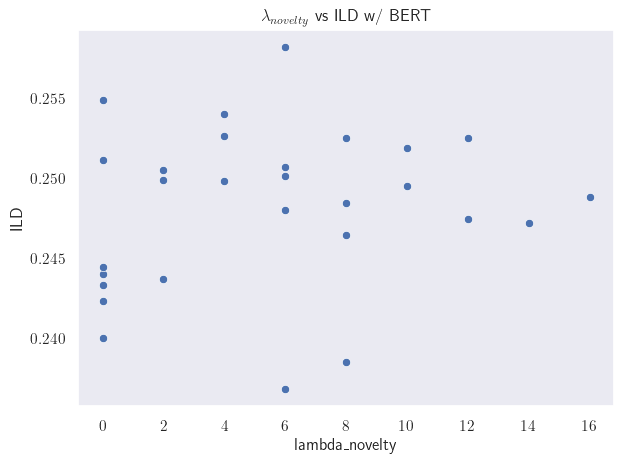

In [55]:
#| fig-cap: "The impact of `lambda_novelty` on ILD"
#| label: fig-lambda_novelty-ILD

ax = sns.scatterplot(nov_tradeoff, x='lambda_novelty', y='ILD')
ax.set_title("$\lambda_{novelty}$ vs ILD  w/ BERT")
plt.tight_layout()

# Novelty is not significant for ILD
res = linregress(nov_tradeoff.lambda_novelty, nov_tradeoff.ILD)
print(f"p-value: {res.pvalue:.2f} coef of determination: {res.rvalue**2:.2f}")

In [ ]:
slope_surprisal = linregress(nov_tradeoff.lambda_novelty, nov_tradeoff.ILD).slope
slope_AUC = linregress(nov_tradeoff.lambda_novelty, nov_tradeoff.AUC).slope

print(f"AUC decreases with {slope_AUC*10:.4f} every 10 in lambda novelty. \nSurprisal rises {slope_surprisal*10:.4f} for every 10 increase.")

AUC decreases with -0.0145 every 100 in lambda novelty. 
Surprisal rises 0.0018 for every 100 increase.


In [61]:
linregress(nov_tradeoff.lambda_novelty, nov_tradeoff.ILD).rvalue**2

0.028141902110879313


---

### div_tradeoff

In [6]:
div_tradeoff = tradeoff_df.query("lambda_novelty == 0")
# div_tradeoff[cols]

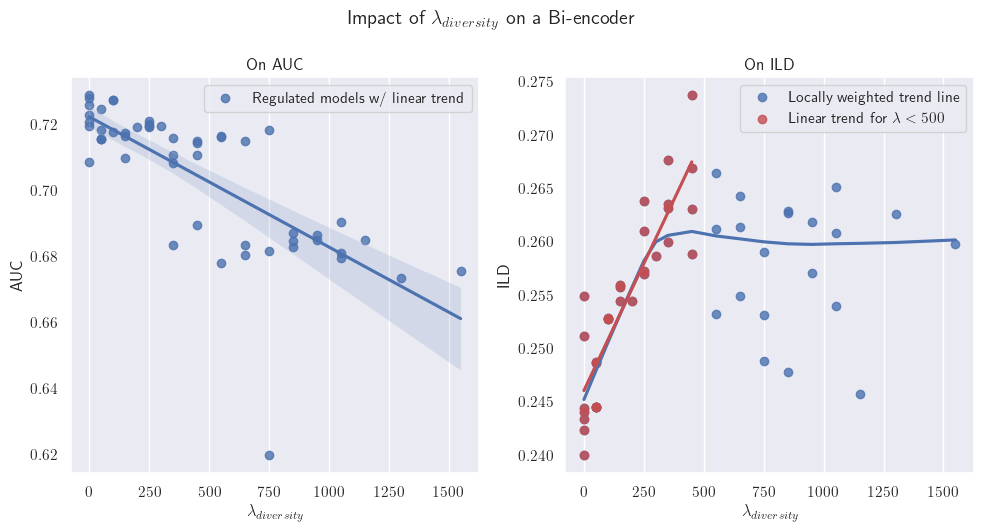

In [7]:
#| fig-cap: "The impact of `lambda_diversity` on AUC and ILD w/ BERT"
#| label: fig-auc-vs-ild-BERT

corr1 = div_tradeoff[['lambda_diversity', 'AUC']].corr().values[1,0]**2
corr2 = div_tradeoff[['ILD', 'lambda_diversity']].corr().values[1,0]**2

fig, axs = plt.subplots(1,2, figsize=(10,5))

sns.regplot(div_tradeoff, x='lambda_diversity', y='AUC', ax=axs[0], label='Regulated models w/ linear trend')

div_tradeoff_500 = div_tradeoff.query('lambda_diversity < 500')
axs[1] = sns.regplot(div_tradeoff, x='lambda_diversity', y='ILD', lowess=True, label='Locally weighted trend line')
sns.regplot(div_tradeoff_500, x='lambda_diversity', y='ILD', color='r', ax=axs[1], ci=False, label='Linear trend for $\lambda<500$')

axs[0].set_title("On AUC")
axs[1].set_title("On ILD")
axs[0].set_xlabel("$\lambda_{diversity}$")
axs[1].set_xlabel("$\lambda_{diversity}$")

axs[0].grid(True, 'major', axis='x')
axs[1].grid(True, 'major', axis='x')

axs[0].legend()
axs[1].legend()

plt.tight_layout()
plt.suptitle('Impact of $\lambda_{diversity}$ on a Bi-encoder', y=1.06)
plt.show()

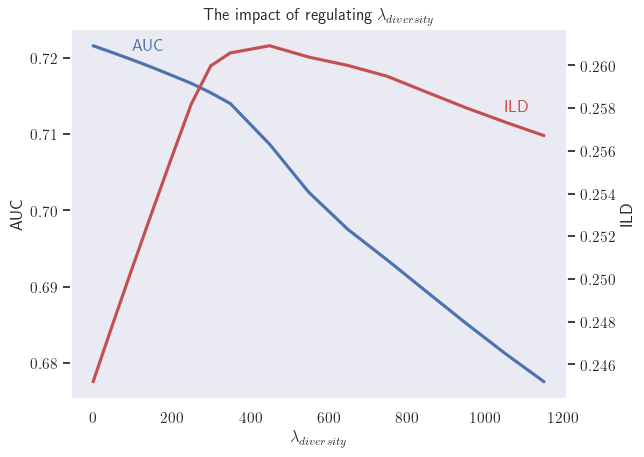

In [ ]:
#| fig-cap: "The impact of regularisation on AUC and ILD"
#| label: fig-impact-of-div-reg

ax = sns.regplot(div_tradeoff.query('lambda_diversity < 1200'), x='lambda_diversity', y='AUC', lowess=True, scatter=False, color='b')
sns.regplot(div_tradeoff.query('lambda_diversity < 1200'), x='lambda_diversity', y='ILD', lowess=True, scatter=False,  ax=ax.twinx(), color='r')
ax.text(1050, 0.713, 'ILD', color='r')
ax.text(100, 0.721, 'AUC', color=' b')

ax.set_xlabel('$\lambda_{diversity}$')
ax.set_title('The impact of regulating $\lambda_{diversity}$')
plt.show()

In [60]:
# Div is significant for ILD
res = linregress(div_tradeoff.lambda_diversity, div_tradeoff.ILD)
print(f"p-value: {res.pvalue:.4f} coef of determination: {res.rvalue**2:.2f}")

p-value: 0.0001 coef of determination: 0.32


In [312]:
# mean line plot
# div_tradeoff.groupby('lambda_diversity')[['lambda_diversity','ILD']].mean().plot.line('lambda_diversity','ILD', marker='o')

In [30]:
# For div_tradeoff_500
res = linregress(div_tradeoff_500.lambda_diversity, div_tradeoff_500.ILD)
res.slope, res.pvalue, res.rvalue**2

(4.760951996772894e-05, 8.632939838125051e-12, 0.7933163402711447)

In [ ]:
# Main insight:
f"An improvement of {res.slope * 500:.4f} ILD requires a sacrifice of {linregress(div_tradeoff_500.lambda_diversity, div_tradeoff_500.AUC).slope * 500:.4f} AUC"

'An improvement of 0.0238 ILD requires a sacrifice of -0.0168 AUC'

In [39]:
linregress(div_tradeoff_500.lambda_diversity, div_tradeoff_500.AUC).rvalue**2

0.30549405933716073

We can also plot the two effects against each other (omitting the independent variable)

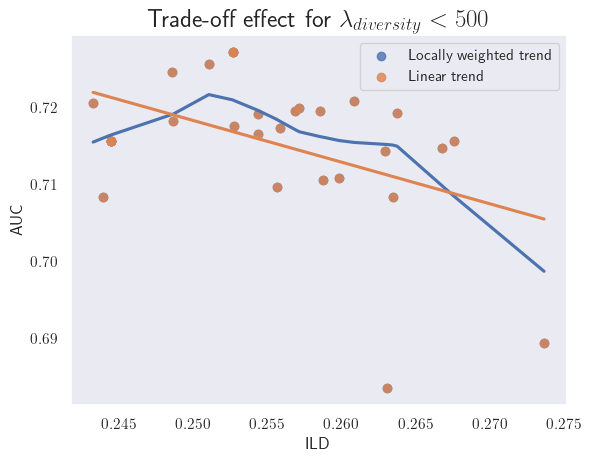

In [63]:
#| fig-cap: "Plotting the trade-off as a linear for small Lambda values (< 500)"
#| label: fig-reg-lambda-500

ax = sns.regplot(div_tradeoff_500, x='ILD', y='AUC', lowess=True, label='Locally weighted trend')
sns.regplot(div_tradeoff_500, x='ILD', y='AUC', ax=ax, label='Linear trend', ci=False)
ax.set_title('Trade-off effect for $\lambda_{diversity} < 500$', fontsize=18)
plt.legend()
plt.show()

In [ ]:
# Key insights on diversity:
slope_ILD = linregress(div_tradeoff_500.lambda_diversity, div_tradeoff_500.ILD).slope
slope_AUC = linregress(div_tradeoff_500.lambda_diversity, div_tradeoff_500.AUC).slope

print(f"AUC decreases with {slope_AUC*100:.4f} every 100 in lambda diversity. \nILD rises {slope_ILD*100:.4f} for every 100 increase.")

AUC decreases with -0.0031 every 100 in lambda diversity. 
ILD rises 0.0047 for every 100 increase.



---

### tradeoff_div_nov

In [63]:
tradeoff_df = df[df.index.str.contains('BERT_')]
cols = ['AUC', 'ILD', 'Surprisal', 'EPC', 'lambda_novelty', 'lambda_diversity',]
tradeoff_div_nov = tradeoff_df #.query('lambda_diversity != 0 and lambda_novelty != 0')

# tradeoff_div_nov[cols].sort_values(['lambda_diversity', 'lambda_novelty'])

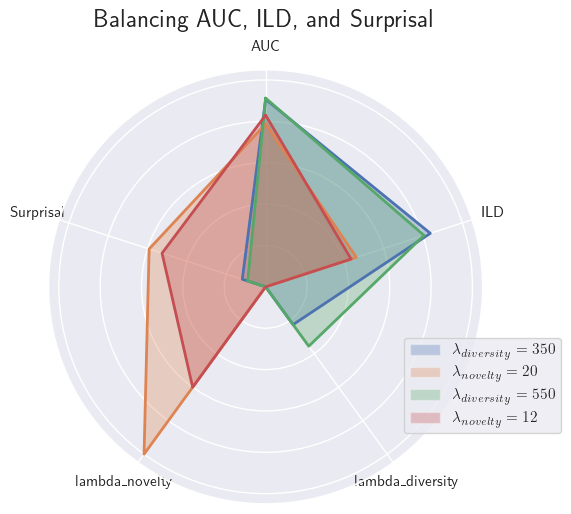

In [ ]:
#| fig-cap: A radar plot of the best all-round models
#| label: fig-radar-best
sns.set_palette("deep") 

top_n = 4
tradeoff_df = df[df.index.str.contains('BERT_')]
tradeoff_div_nov = tradeoff_df.query('AUC > 0.60') #lambda_diversity != 0 and lambda_novelty != 0 and 

tradeoff_div_nov = tradeoff_div_nov.rename(index={
   'BERT_sm_div350_v3': '$\lambda_{diversity}=350$', 'BERT_sm_20': '$\lambda_{novelty}=20$', 'BERT_sm_div550_v2': '$\lambda_{diversity}=550$', 'BERT_sm_12': '$\lambda_{novelty}=12$'})

cols = ['AUC', 'Surprisal', 'lambda_novelty', 'lambda_diversity', 'ILD']
df_normalised = tradeoff_div_nov[cols].copy()
df_normalised = (df_normalised - df_normalised.min()) / (df_normalised.max() - df_normalised.min())

top_idxs = (df_normalised.AUC + df_normalised.ILD + df_normalised.Surprisal).sort_values(ascending=False).index

top_models = df_normalised.loc[top_idxs[:top_n]]

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(10, 5))  
ax.set_theta_offset(np.pi / 2)

angles = np.linspace(0, 2 * np.pi, len(cols), endpoint=False).tolist()
angles += angles[:1]

for i in range(top_n):
    values = top_models.iloc[i].tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.3, label=top_models.index[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cols)
    ax.set_yticklabels([])

plt.tight_layout()
plt.legend(bbox_to_anchor=(0.8, 0.4), loc='upper left')
plt.title('Balancing AUC, ILD, and Surprisal', y=1.08, fontsize=18)
plt.show()

In [ ]:
#| tbl-cap: Two legs of optimisation
#| label: tbl-radar-tradeoff-nov-div

cols = ['AUC', 'ILD', 'Surprisal', 'lambda_novelty', 'lambda_diversity']
# radar_table = tradeoff_div_nov.loc[top_idxs[:top_n]][cols]
tradeoff_div_nov.loc[top_idxs[:4]][cols].set_index(['lambda_novelty', 'lambda_diversity'])


,,AUC,ILD,Surprisal
lambda_novelty,lambda_diversity,,,
0.0,350.0,0.7157,0.2676,7.7572
20.0,0.0,0.7009,0.2535,8.4735
0.0,550.0,0.7164,0.2664,7.7157
12.0,0.0,0.7062,0.2525,8.3742


In [82]:
tradeoff_df = df[df.index.str.contains('BERT_')]
tradeoff_div_nov = tradeoff_df.query('AUC > 0.65') #lambda_diversity != 0 and 

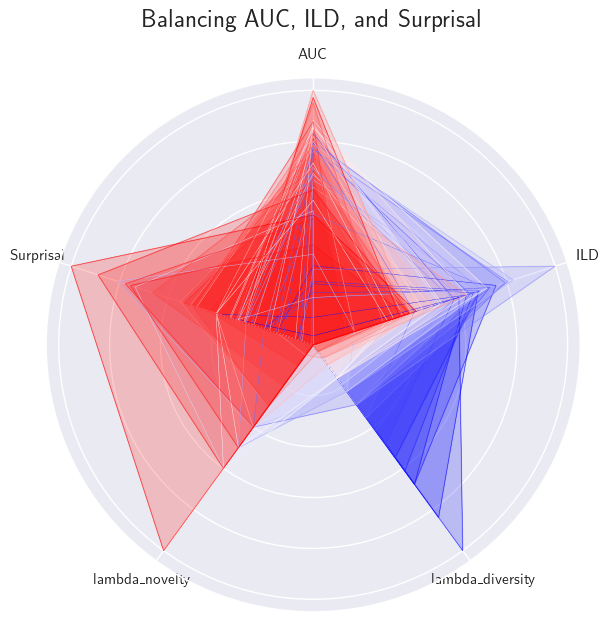

In [ ]:
#| fig-cap: "Two legs of optimisation: gains are either in diversity or novelty, but rarely both"
#| label: fig-radar-tradeoff-nov-div

tradeoff_df = df[df.index.str.contains('BERT_')]
tradeoff_div_nov = tradeoff_df.query('AUC > 0.65') #lambda_diversity != 0 and lambda_novelty != 0 and 

top_n = tradeoff_div_nov.shape[0] # ALL
df_normalised = tradeoff_div_nov[cols].copy()
df_normalised = (df_normalised - df_normalised.min()) / (df_normalised.max() - df_normalised.min())
df_normalised = df_normalised.sort_values('lambda_novelty').sort_values('lambda_diversity', ascending=False)

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(10, 6))  
ax.set_theta_offset(np.pi / 2)

angles = np.linspace(0, 2 * np.pi, len(cols), endpoint=False).tolist()
angles += angles[:1]

colors = plt.get_cmap('bwr')(np.linspace(0, 1, top_n)) #cc.cm.diverging_bwg_20_95_c41

for i in range(top_n):

    values = df_normalised.iloc[i].tolist()
    values += values[:1]
    
    ax.plot(angles, values, color=colors[i], lw=0.3)
    ax.fill(angles, values, alpha=0.2, color=colors[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cols)
    ax.set_yticklabels([])

plt.tight_layout()

plt.title('Balancing AUC, ILD, and Surprisal', y=1.08, fontsize=18)
plt.show()

# tradeoff_div_nov.loc[top_idxs[:top_n]][cols]

The regularisation losses fall into two patterns: 
- we turn up div and to a lesser extent novelty, and ILD increases with too much AUC reduction, or
- we drastically turn up novelty and see increases in surprisal, at a cost of AUC

In this plot we see a two-legged pentagon emerging. Increasing both together isn't possible, as the AUC falls back or remains stuck around 0.5. 

In [68]:
# Looking at the residuals, we see that the 
# div = tradeoff_df[tradeoff_df.index.str.contains('BERT_')][tradeoff_df.lambda_diversity > 0]
# nov = tradeoff_df[tradeoff_df.index.str.contains('BERT_')][tradeoff_df.lambda_novelty > 0]

# fig, axs = plt.subplots(1,2, figsize=(12,6))
# sns.residplot(nov, x='lambda_novelty', y='AUC', lowess=True, ax=axs[0])
# sns.residplot(div, x='lambda_diversity', y='AUC', lowess=True, ax=axs[1])


---

## Statistical analysis

We will now use the saved prediction arrays to get more insight into session-level distributions.

In [ ]:
# all = df.sort_values('AUC', ascending=False)[cols]

In [93]:
data = DataLoader()
histories, data.test_imprs, labels = data.init_padded_behaviors(data.test)
ds = data.get_dataset(data.test) # gets data.test_labels
del ds

In [94]:
embedding_matrix = np.load(data_folder/'embedding_matrix_small_cls.npy') # bert 
embedding_matrix.shape

(65239, 768)

In [122]:
# list(data_folder.glob('*.npy'))

In [355]:
for pred_path in data_folder.glob('*.npy'):
    if 'BERT_sm' in pred_path.as_posix():  
        print(pred_path)

../.data/BERT_sm_div450_v2.npy
../.data/BERT_sm_div400_v3.npy
../.data/BERT_sm_12.npy
../.data/BERT_sm_div350_nov16_v2.npy
../.data/BERT_sm_div350_v3.npy
../.data/BERT_sm_div150.npy
../.data/BERT_sm_div350_nov10_v2.npy
../.data/BERT_sm_18.npy
../.data/BERT_sm_div1150_v3.npy
../.data/BERT_sm_div650_v3.npy
../.data/BERT_sm_div250_v3.npy
../.data/BERT_sm_div1550.npy
../.data/BERT_sm_div250_v2.npy
../.data/BERT_sm_div550.npy
../.data/BERT_sm_0.npy
../.data/BERT_sm_div300_v3.npy
../.data/BERT_sm_div250_nov12.npy
../.data/BERT_sm_div550_v3.npy
../.data/BERT_sm_div750_v3.npy
../.data/BERT_sm_div750_v2.npy
../.data/BERT_sm_div100_v2.npy
../.data/BERT_sm_div350.npy
../.data/BERT_sm_div250_nov14_v2.npy
../.data/BERT_sm_div1050_v3.npy
../.data/BERT_sm_div450_v3.npy
../.data/BERT_sm_div450.npy
../.data/BERT_sm_16.npy
../.data/BERT_sm_div1050.npy
../.data/BERT_sm_div850.npy
../.data/BERT_sm_div50_v2.npy
../.data/BERT_sm_div450_nov18_v2.npy
../.data/BERT_sm_div550_v2.npy
../.data/BERT_sm_div250_nov1

In [ ]:
# best
y_pred_best = np.load(data_folder/'BERT_sm_div450.npy') # auc of 0.6894, ild of 0.2737, and lambda div of 450.0
ild_best = intra_list_diversity(y_pred_best, data.test_imprs, embedding_matrix, 5)
# np.nanmean(ild)

y_pred_ref = np.load(data_folder/'Random_Recommender_sm.npy')
ild_ref = intra_list_diversity(y_pred_ref, data.test_imprs, embedding_matrix, 5)
# np.nanmean(ild_ref)

y_pred_pop = np.load(data_folder/'Popularity_Recommender_sm.npy')
ild_pop = intra_list_diversity(y_pred_pop, data.test_imprs, embedding_matrix, 5)
# np.nanmean(ild_pop)

y_pred_no = np.load(data_folder/'BERT_sm_0.npy')
ild_no = intra_list_diversity(y_pred_no, data.test_imprs, embedding_matrix, 5)
# np.nanmean(ild_no)

y_pred_cb = np.load(data_folder/'Content-based_filtering_sm.npy')
ild_cb = intra_list_diversity(y_pred_cb, data.test_imprs, embedding_matrix, 5)
# np.nanmean(ild_cb)

y_pred_msn = np.load(data_folder/'MSN_Recommender_sm.npy')
ild_msn = intra_list_diversity(y_pred_msn, data.test_imprs, embedding_matrix, 5)

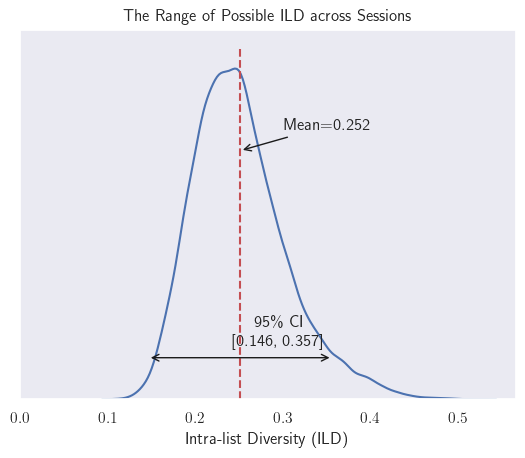

In [ ]:
#| fig-cap: Standard error of ILD across sessions
#| label: fig-random-stderr-ild

sns.kdeplot(x=ild_ref[~np.isnan(ild_ref)])

# mean and 95% CI
mean = np.nanmean(ild_ref)
std_err = np.nanstd(ild_ref, ddof=1) 
ci_low = mean - 1.96 * std_err 
ci_high = mean + 1.96 * std_err 

# Plot vertical mean line
plt.vlines(mean, ymin=0, ymax=8.5, colors='r', linestyles='--')

# horizontal CI line with arrows
plt.annotate(
    "", xy=(ci_low, 1), xytext=(ci_high, 1),
    arrowprops=dict(arrowstyle="<->", color="k"))

# Add label
plt.text((ci_low + ci_high) / 1.7 , 1 + 0.3, f"95\% CI\n[{ci_low:.3f}, {ci_high:.3f}]", ha='center')

plt.annotate(f"Mean={mean:.3f}", (mean, 6), (mean+0.05, 6.5), arrowprops=dict(arrowstyle="->", color="k"))

plt.ylabel('')
plt.yticks([])
plt.title('The Range of Possible ILD across Sessions')
plt.xlim(left=0)
plt.xlabel('Intra-list Diversity (ILD)')

plt.show()

> while the core metric is a mean of means, the random range shows a slight skew, with a more sessions with an ILD of just over 0.2. However, while the slope on the left is steep, there's a heavy tail lifting up towards 0.4.

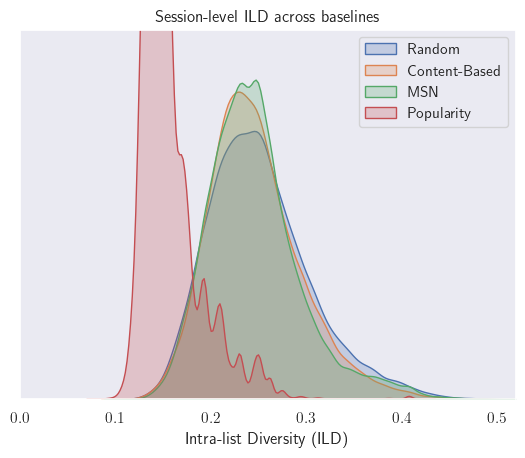

In [339]:
#| fig-cap: "Session-level ILD across baselines"
#| label: fig-baselines-ILD

ax = sns.kdeplot(x=ild_ref[~np.isnan(ild_ref)], fill=True, label='Random')
sns.kdeplot(ild_cb[~np.isnan(ild_cb)], ax=ax, fill=True, label='Content-Based')
sns.kdeplot(ild_msn[~np.isnan(ild_msn)], ax=ax, fill=True, label='MSN')
sns.kdeplot(ild_pop[~np.isnan(ild_pop)], ax=ax, fill=True, label='Popularity')

ax.set_title('Session-level ILD across baselines')
plt.ylabel('')
plt.yticks([])
plt.xlim(0,0.52)
plt.ylim(0,11)
plt.xlabel('Intra-list Diversity (ILD)')
plt.legend()
plt.show()

Text(0, 0.5, 'Measurements')

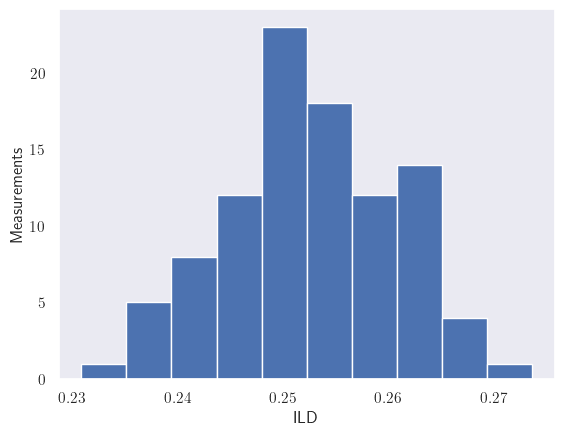

In [367]:
# this may be more insightful, actually: the range of measured values is very narrow
ax = df.query('ILD > 0.18').ILD.plot.hist()
ax.set_xlabel('ILD')
ax.set_ylabel('Measurements')

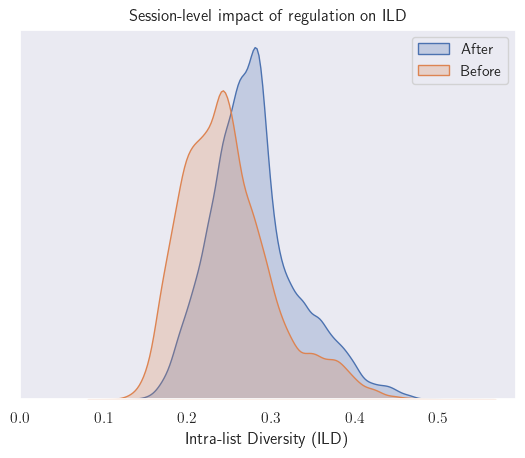

In [320]:
#| fig-cap: "ILD before and after regularisation"
#| label: fig-before-after-reg

ax = sns.kdeplot(ild_best[~np.isnan(ild_ref)], label='After', fill=True)
sns.kdeplot(ild_no[~np.isnan(ild_ref)], ax=ax, label='Before', fill=True)

plt.ylabel('')
plt.yticks([])
plt.xlim(left=0)
plt.xlabel('Intra-list Diversity (ILD)')
ax.set_title('Session-level impact of regulation on ILD')
plt.legend()
plt.show()

In [ ]:
t_test = ttest_rel(ild_no[~np.isnan(ild_no)], ild_best[~np.isnan(ild_no)], alternative='less')

t_test.pvalue, t_test.statistic

(0.0, -112.44247440502289)


## Surprisal 

In [ ]:
# Random
y_pred_ref = np.load(data_folder/'Random_Recommender_sm.npy')
surprisal_ref = surprisal(data.test_labels, y_pred_ref, data.test_imprs, 5)
np.mean(surprisal_ref)

10.891323512210189

In [ ]:
# best > this is less straightforward: is actually 13th! 
# many collapsed, with AUC 0.5-0.6, cb-filtering, msn, and cross-encoder, 
# but very good with surprisal of 8.3742 with lambda nov of 12, and AUC 0.7062
y_pred_best = np.load(data_folder/'BERT_sm_12.npy')
surprisal_best = surprisal(data.test_labels, y_pred_best, data.test_imprs, 5)

y_pred_no = np.load(data_folder/'BERT_sm_0.npy')
surprisal_no = surprisal(data.test_labels, y_pred_no, data.test_imprs, 5)

In [99]:
# Better best
y_pred_best = np.load(data_folder/'BERT_sm_14.npy')
surprisal_best = surprisal(data.test_labels, y_pred_best, data.test_imprs, 5)

In [98]:
# Baselines
y_pred_pop = np.load(data_folder/'Popularity_Recommender_sm.npy')
surprisal_pop = surprisal(data.test_labels, y_pred_pop, data.test_imprs, 5)


y_pred_cb = np.load(data_folder/'Content-based_filtering_sm.npy')
surprisal_cb = surprisal(data.test_labels, y_pred_cb, data.test_imprs, 5)

y_pred_msn = np.load(data_folder/'MSN_Recommender_sm.npy')
surprisal_msn = surprisal(data.test_labels, y_pred_msn, data.test_imprs, 5)

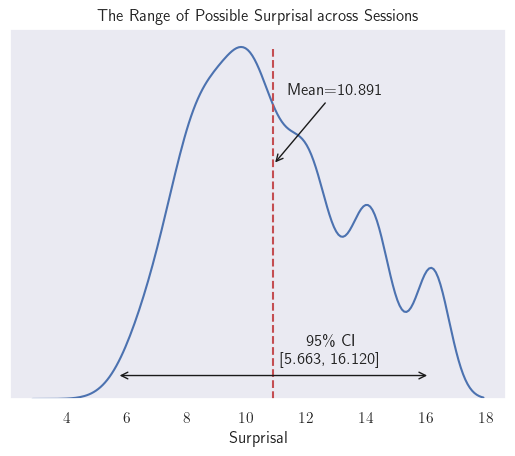

In [ ]:
#| fig-cap: Standard error of ILD across sessions
#| label: fig-random-stderr-surprisal

sns.kdeplot(x=surprisal_ref, bw_adjust=2)

# mean and 95% CI
mean = np.mean(surprisal_ref)
std_err = np.std(surprisal_ref, ddof=1) 
ci_low = mean - 1.96 * std_err 
ci_high = mean + 1.96 * std_err 

# Plot vertical mean line
plt.vlines(mean, ymin=0, ymax=0.15, colors='r', linestyles='--')

# horizontal CI line with arrows
plt.annotate(
    "", xy=(ci_low, 0.01), xytext=(ci_high, 0.01),
    arrowprops=dict(arrowstyle="<->", color="k"))

# # Add label
plt.text((ci_low + ci_high) / 1.7 , 0.015, f"95\% CI\n[{ci_low:.3f}, {ci_high:.3f}]", ha='center')

plt.annotate(f"Mean={mean:.3f}", (mean, 0.1), (mean+0.5, 0.13), arrowprops=dict(arrowstyle="->", color="k"))

plt.ylabel('')
plt.yticks([])
plt.title('The Range of Possible Surprisal across Sessions')
plt.ylim(bottom=0)
plt.xlabel('Surprisal')

plt.show()

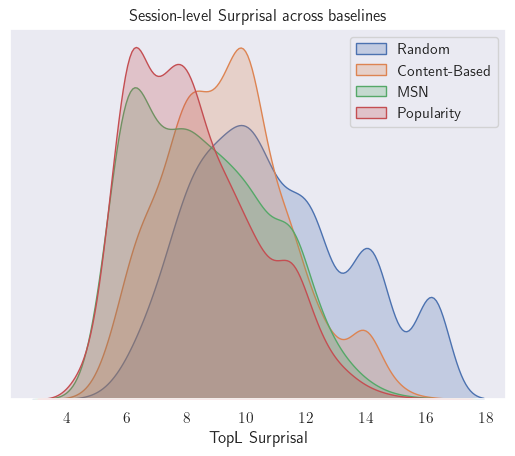

In [ ]:
#| fig-cap: "Session-level Surprisal across baselines"
#| label: fig-baselines-surprisal

ax = sns.kdeplot(surprisal_ref, fill=True, label='Random', bw_adjust=2)
sns.kdeplot(surprisal_cb, ax=ax, fill=True, label='Content-Based', bw_adjust=2)
sns.kdeplot(surprisal_msn, ax=ax, fill=True, label='MSN', bw_adjust=2)
sns.kdeplot(surprisal_pop, ax=ax, fill=True, label='Popularity', bw_adjust=2)

ax.set_title('Session-level Surprisal across baselines')
plt.ylabel('')
plt.yticks([])
# plt.xlim(0,0.52)
# plt.ylim(0,11)
plt.xlabel('TopL Surprisal')
plt.legend()
plt.show()

In [350]:
np.mean(surprisal_no)

8.013264390737769

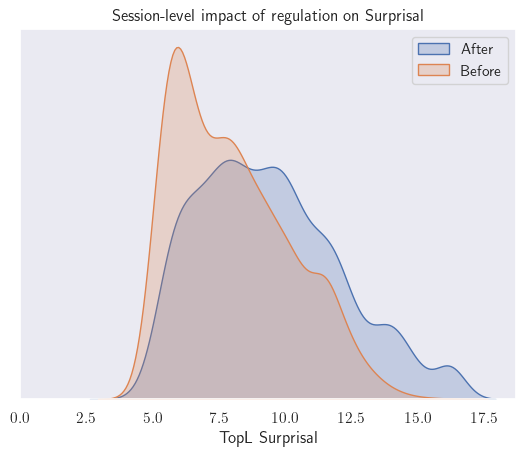

In [101]:
#| fig-cap: "Surprisal before and after regularisation"
#| label: fig-before-after-novelty-reg

ax = sns.kdeplot(surprisal_best, label='After', fill=True, bw_adjust=2)
sns.kdeplot(surprisal_no, ax=ax, label='Before', fill=True, bw_adjust=2)

plt.ylabel('')
plt.yticks([])
plt.xlim(left=0)
plt.xlabel('TopL Surprisal')
ax.set_title('Session-level impact of regulation on Surprisal')
plt.legend()
plt.show()

In [102]:
t_test = ttest_rel(surprisal_no, surprisal_best, alternative='less')
t_test.pvalue, t_test.statistic

(0.0, -188.4112882670724)


--- 

## Examples

In [25]:
reference_pred = np.load(data_folder/'BERT_sm_0.npy')
best_nov_pred = np.load(data_folder/'BERT_sm_14.npy')
best_div_pred = np.load(data_folder/'BERT_sm_div450.npy')

In [27]:
df[df.index.str.contains('BERT_sm_14')][cols]

,AUC,MRR,nDCG@5,nDCG@10,EPC,ILD,Surprisal,Coverage
BERT_sm_14,0.5925,0.2585,0.2761,0.3449,1.6757,0.2405,9.3951,0.3109


In [4]:
data = DataLoader()
histories, data.test_imprs, labels = data.init_padded_behaviors(data.test)
ds = data.get_dataset(data.test)
del ds

In [16]:
order = np.argsort(reference_pred, axis=1)[:, ::-1]

def display_example(idx):    
    imprs_ranked = np.take(data.test_imprs, order)[idx]    
    default_ranking = list(range(1, len(imprs_ranked)+1))

    best_nov_pred_ranked = np.take(best_nov_pred, order)[idx]
    nov_ranking = np.argsort(np.argsort(-best_nov_pred_ranked)) + 1

    best_div_pred_ranked = np.take(best_div_pred, order)[idx]
    div_ranking = np.argsort(np.argsort(-best_div_pred_ranked)) + 1
    ranked_recs = [n.decode() for n in data.news_titles.numpy()[imprs_ranked]]
    ranked_recs = [rec[:65] + "..." if len(rec) > 65 else rec for rec in ranked_recs ]    
    df = pd.DataFrame(
            {'Best': default_ranking, 
             'Novel': nov_ranking, 
             'Diverse': div_ranking}, 
             index=ranked_recs).drop('')
    df.columns.name = 'Articles'
    display(df)

In [17]:
#| label: tbl-example
#| tbl-cap: Illustating the differences in rankings (1)

display_example(0)

Articles,Best,Novel,Diverse
Cows swept away by Hurricane Dorian found alive but how?,1,4,9
THEN AND NOW: What all your favorite '90s stars are doing today,2,12,11
Opinion: Colin Kaepernick is about to get what he deserves: a cha...,3,14,7
"Browns apologize to Mason Rudolph, call Myles Garrett's actions '...",4,2,4
Meghan Markle and Hillary Clinton Secretly Spent the Afternoon To...,5,5,8
"Taylor Swift Rep Hits Back at Big Machine, Claims She's Actually ...",6,3,3
The Unlikely Star of My Family's Thanksgiving Table,7,7,13
13 Reasons Why's Christian Navarro Slams Disney for Casting 'the ...,8,10,6
Survivor Contestants Missy Byrd and Elizabeth Beisel Apologize Fo...,9,21,2
"Pete Davidson, Kaia Gerber Are Dating, Trying to Stay 'Low Profil...",10,11,5


In [18]:
#| label: tbl-example-1
#| tbl-cap: Illustating the differences in rankings (2)
display_example(1) 

Articles,Best,Novel,Diverse
THEN AND NOW: What all your favorite '90s stars are doing today,1,12,11
Opinion: Colin Kaepernick is about to get what he deserves: a cha...,2,14,7
"U.S. Troops Will Die If They Remain in Syria, Bashar Al-Assad War...",3,22,17
Report: Police investigating woman's death after Redskins' player...,4,16,1
I've been writing about tiny homes for a year and finally spent 2...,5,15,22
"Browns apologize to Mason Rudolph, call Myles Garrett's actions '...",6,2,4
The Kardashians Face Backlash Over 'Insensitive' Family Food Figh...,7,8,15
Meghan Markle and Hillary Clinton Secretly Spent the Afternoon To...,8,5,8
3 Indiana judges suspended after a night of drinking turned into ...,9,13,12
Cows swept away by Hurricane Dorian found alive but how?,10,4,9


In [ ]:
#| label: tbl-example-2
#| tbl-cap: Illustating the differences in rankings (3)

display_example(2) 

Articles,Best,Novel,Diverse
Meghan Markle and Hillary Clinton Secretly Spent the Afternoon To...,1,5,8
There's a place in the US where its been over 80 degrees since Ma...,2,18,16
66 Cool Tech Gifts Anyone Would Be Thrilled to Receive,4,9,18
The Kardashians Face Backlash Over 'Insensitive' Family Food Figh...,5,8,15
Belichick mocks social media in comments on Garrett incident,6,6,19
I've been writing about tiny homes for a year and finally spent 2...,7,15,22
"Pete Davidson, Kaia Gerber Are Dating, Trying to Stay 'Low Profil...",8,11,5
"U.S. Troops Will Die If They Remain in Syria, Bashar Al-Assad War...",9,22,17
13 Reasons Why's Christian Navarro Slams Disney for Casting 'the ...,10,10,6
"Browns apologize to Mason Rudolph, call Myles Garrett's actions '...",11,2,4


In [22]:
# Sense check
idx = 0
order = np.argsort(reference_pred, axis=1)[:, ::-1]
imprs_ranked = np.take(data.test_imprs, order)[idx]    
ranked_recs = [n.decode() for n in data.news_titles.numpy()[imprs_ranked]]
ranked_recs = [rec[:65] + "..." if len(rec) > 65 else rec for rec in ranked_recs ]    

df = pd.DataFrame(
        {'Best': np.take(reference_pred, order)[idx]   , 
        'Novel': np.take(best_nov_pred, order)[idx], 
        'Diverse': np.take(best_div_pred, order)[idx]}, 
        index=ranked_recs).drop('')
df.columns.name = 'Articles'
df.style.text_gradient()

Articles,Best,Novel,Diverse
Cows swept away by Hurricane Dorian found alive but how?,0.089377,0.081629,0.050753
THEN AND NOW: What all your favorite '90s stars are doing today,0.070979,0.032812,0.044948
Opinion: Colin Kaepernick is about to get what he deserves: a cha...,0.064407,0.032192,0.054326
"Browns apologize to Mason Rudolph, call Myles Garrett's actions '...",0.058380,0.089324,0.065225
Meghan Markle and Hillary Clinton Secretly Spent the Afternoon To...,0.054148,0.066097,0.051201
"Taylor Swift Rep Hits Back at Big Machine, Claims She's Actually ...",0.054122,0.086387,0.066351
The Unlikely Star of My Family's Thanksgiving Table,0.053332,0.046375,0.039702
13 Reasons Why's Christian Navarro Slams Disney for Casting 'the ...,0.052761,0.040001,0.056866
Survivor Contestants Missy Byrd and Elizabeth Beisel Apologize Fo...,0.050842,0.012499,0.068830
"Pete Davidson, Kaia Gerber Are Dating, Trying to Stay 'Low Profil...",0.050039,0.034828,0.061741
